# 04 - Neural Network

Train, validate, and evaluate the MLP battery-sizing model via `src.ai.neural_network`, using the same features and splits as the baselines for a fair comparison.


**Status:** placeholder created in Stage 1 (project scaffold). Populated in Stage 6 (neural network).

This notebook is intentionally thin: it should only call reusable functions from `src/`, never contain modelling logic itself (PROJECT_BRIEF.md §25, §1.6).


In [1]:
# Colab-aware bootstrap: on Google Colab, clone the repo (or pull the latest
# commits into an existing clone) and install dependencies automatically --
# no manual setup cell needed. Locally / outside Colab, this only fixes
# sys.path, exactly as before.
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/sulhos/Leonardo-Assignment.git"
BRANCH = "claude/repository-project-prompt-or0ida"
REPO_DIRNAME = "Leonardo-Assignment"
MARKER_FILE = "PROJECT_BRIEF.md"  # present only at the real project root

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    search_dirs = [Path.cwd(), Path.cwd() / REPO_DIRNAME]
    repo_root = next((d for d in search_dirs if (d / MARKER_FILE).is_file()), None)

    if repo_root is None:
        print(f"Cloning {REPO_URL} (branch {BRANCH})...")
        subprocess.run(["git", "clone", "-b", BRANCH, REPO_URL], check=True)
        repo_root = Path.cwd() / REPO_DIRNAME
    else:
        print(f"Found existing clone at {repo_root} -- hard-syncing to origin/{BRANCH}...")
        # Hard sync (fetch + reset --hard), not `git pull`: a plain pull can leave
        # a Colab VM's reused (not freshly cloned) checkout on stale tracked files
        # if the local branch has drifted or a merge doesn't fast-forward cleanly --
        # this bit twice (stale `src/` imports surviving a "fresh" notebook run on a
        # reconnected-but-not-recreated Colab runtime). Fetch+reset always makes the
        # tracked files exactly match origin/BRANCH; it never touches untracked/
        # gitignored files (e.g. the cached weather downloads), so nothing is lost.
        subprocess.run(["git", "fetch", "origin", BRANCH], check=True, cwd=str(repo_root))
        subprocess.run(["git", "reset", "--hard", f"origin/{BRANCH}"], check=True, cwd=str(repo_root))

    os.chdir(repo_root)
    PROJECT_ROOT = Path.cwd()
    print(f"Working directory: {PROJECT_ROOT}")

    # Skip jupyter/ipykernel: Colab already provides its own pinned versions,
    # and reinstalling them can destabilize the running kernel.
    requirements = [
        line for line in Path("requirements.txt").read_text().splitlines()
        if line.strip() and not line.strip().startswith("#")
        and not line.lower().startswith(("jupyter", "ipykernel"))
    ]
    req_path = Path("/tmp/requirements_colab.txt")
    req_path.write_text("\n".join(requirements))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(req_path)], check=True)
    print("Dependencies installed.")
else:
    PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Defensive: evict any already-imported src.* modules from Python's module
# cache. The git sync above only fixes what's on *disk* -- if this cell runs
# in a kernel/runtime that already imported an old version of e.g.
# src.ai.neural_network earlier in the session (Colab can silently reconnect
# you to an already-running backend instead of starting a fresh one, even
# after fully closing and reopening the browser tab), Python's import system
# would keep serving that stale cached module object and ignore the sync
# entirely. Deleting the cache entries forces every subsequent `from src...
# import ...` below to re-read the just-synced file.
for _mod_name in list(sys.modules):
    if _mod_name == "src" or _mod_name.startswith("src."):
        del sys.modules[_mod_name]


In [2]:
import time
import pandas as pd

from src.config import load_site_config, load_yaml_config
from src.data.weather import get_processed_weather
from src.ai.features import build_feature_matrix
from src.ai.splitting import split_experiment_a
from src.ai.preprocessing import fit_scaler, save_preprocessing_objects
from src.ai.neural_network import build_model, predict, set_global_seed, train_model
from src.ai.evaluation import compute_accuracy_metrics, compute_operational_metrics
from src.visualization.plotting import (
    plot_cross_model_metric_comparison, plot_over_under_prediction_rates,
    plot_predicted_vs_reference, plot_residual_distribution, plot_training_history, save_figure,
)

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
MODELS_DIR = PROJECT_ROOT / "models"
ml_cfg = load_yaml_config("ml_training")
site_config = load_site_config("jinan")
ml_cfg["neural_network"]

I0000 00:00:1784608051.134845   26306 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784608051.137425   26306 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784608051.325637   26306 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784608053.270883   26306 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784608053.272663   26306 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


{'framework': 'keras',
 'architecture': {'hidden_layers': [128, 64, 32],
  'activation': 'relu',
  'dropout_after_first_layer': 0.1,
  'output_activation': 'relu'},
 'training': {'loss': 'huber',
  'optimizer': 'adam',
  'learning_rate': 0.001,
  'batch_size': 32,
  'max_epochs': 500,
  'early_stopping': {'monitor': 'val_loss',
   'patience': 20,
   'restore_best_weights': True},
  'checkpoint': {'monitor': 'val_loss', 'save_best_only': True}},
 'reproducibility': {'fixed_seed': True,
  'note': 'Full determinism is not guaranteed on GPU backends; document any run-to-run variance observed in Stage 6.\n'}}

## Same data, features, and split as Stage 5

For a fair comparison, the neural network uses exactly the same 56 feasible scenarios, the same 37 engineered features, and the same 39/8/9 Experiment A split as the Stage 5 baselines -- only the scaler differs (the NN needs standardized inputs; the tree-based baseline didn't, though Ridge implicitly benefits from it too).

In [3]:
scenarios = pd.read_csv(PROJECT_ROOT / "data" / "scenarios" / "pilot_scenarios.csv")
feasible = scenarios[scenarios["feasible"]].reset_index(drop=True)
weather = get_processed_weather("jinan", 2023)
features = build_feature_matrix(feasible, weather, site_config)
merged = features.merge(feasible[["scenario_id", "optimal_capacity_kwh"]], on="scenario_id")
feature_columns = [c for c in features.columns if c != "scenario_id"]

splits = split_experiment_a(merged, group_column="scenario_id", random_seed=ml_cfg["random_seed"])
print({k: len(v) for k, v in splits.items()})

X_train, y_train = merged.loc[splits["train"], feature_columns], merged.loc[splits["train"], "optimal_capacity_kwh"]
X_val, y_val = merged.loc[splits["val"], feature_columns], merged.loc[splits["val"], "optimal_capacity_kwh"]
X_test, y_test = merged.loc[splits["test"], feature_columns], merged.loc[splits["test"], "optimal_capacity_kwh"]

{'train': 27, 'val': 5, 'test': 7}


## Standardize inputs (scaler fit on training data only)

In [4]:
scaler = fit_scaler(X_train)
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=feature_columns, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=feature_columns, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_columns, index=X_test.index)

save_preprocessing_objects(
    {"scaler": scaler, "feature_columns": feature_columns},
    MODELS_DIR / "preprocessing",
)

## Build and train the MLP

Architecture and training hyperparameters come entirely from `config/ml_training.yaml` -> `neural_network` (128-64-32 with 10% dropout after the first layer, Huber loss, Adam, early stopping on `val_loss` with patience 20, best-model checkpointing) -- nothing is hard-coded in this notebook.

In [5]:
set_global_seed(ml_cfg["random_seed"])
model = build_model(n_features=len(feature_columns), config=ml_cfg["neural_network"])
model.summary()

E0000 00:00:1784608056.210157   26306 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "battery_capacity_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 37)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capacity_kwh (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,233 (59.50 KB)

 Trainable params: 15,233 (59.50 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
t0 = time.perf_counter()
model, history = train_model(
    model, X_train_scaled, y_train, X_val_scaled, y_val,
    ml_cfg["neural_network"], MODELS_DIR / "neural_network",
)
nn_train_seconds = time.perf_counter() - t0
n_epochs_trained = len(history.history["loss"])
print(f"Trained for {n_epochs_trained} epochs in {nn_train_seconds:.1f}s "
      f"(best val_loss={min(history.history['val_loss']):.3f})")

Trained for 173 epochs in 17.1s (best val_loss=1448.221)


## Required figure: training/validation loss (PROJECT_BRIEF.md §27, figure 16)

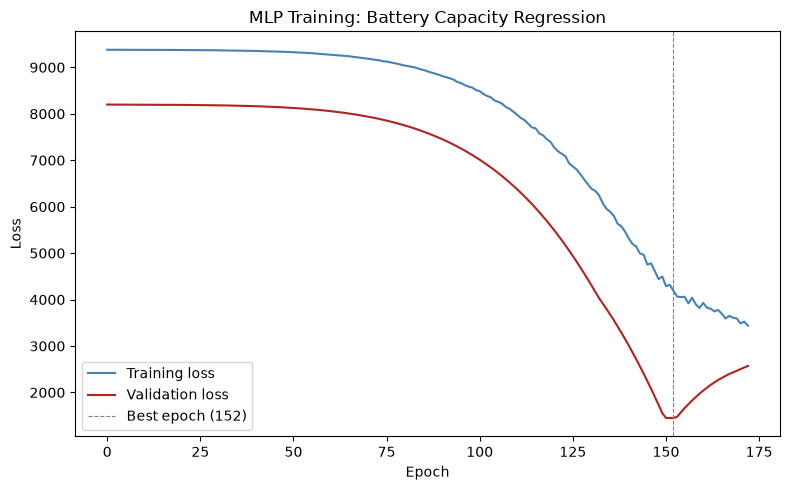

In [7]:
fig = plot_training_history(history.history, "MLP Training: Battery Capacity Regression")
save_figure(fig, FIGURES_DIR / "16_training_validation_loss.png")

## Evaluate on the held-out test split

In [8]:
nn_pred = predict(model, X_test_scaled)
print("Predictions:", nn_pred)
print("Any negative:", (nn_pred < 0).any())

nn_accuracy = compute_accuracy_metrics(y_test, nn_pred)
nn_operational = compute_operational_metrics(y_test, nn_pred)
pd.DataFrame({"neural_network": nn_accuracy}).T

Predictions: [1738.8694 6472.603  2376.7573 7360.44   4042.4243 1552.3317 4994.5723]
Any negative: False


,mae,rmse,r2,median_absolute_error,mape,max_absolute_error,mean_signed_error_bias,pct_within_5pct,pct_within_10pct,pct_within_20pct,n_samples
neural_network,6311.84028,7570.764333,-0.926109,6123.242676,0.612656,12707.575684,-5637.428868,0.0,0.0,0.0,7.0


In [9]:
pd.DataFrame({"neural_network": nn_operational}).T

,underprediction_rate,overprediction_rate,exact_match_rate,mean_underprediction_kwh,max_underprediction_kwh,mean_overprediction_kwh,max_overprediction_kwh
neural_network,0.857143,0.142857,0.0,6970.407003,12707.575684,2360.439941,2360.439941


## Compare against the Stage 5 baselines

In [10]:
baseline_accuracy = pd.read_csv(TABLES_DIR / "accuracy_metrics_by_model.csv", index_col=0)
baseline_operational = pd.read_csv(TABLES_DIR / "reliability_metrics_by_model.csv", index_col=0)

all_accuracy = pd.concat([baseline_accuracy, pd.DataFrame({"neural_network": nn_accuracy}).T])
all_operational = pd.concat([baseline_operational, pd.DataFrame({"neural_network": nn_operational}).T])
all_accuracy.to_csv(TABLES_DIR / "accuracy_metrics_by_model.csv")
all_operational.to_csv(TABLES_DIR / "reliability_metrics_by_model.csv")
all_accuracy[["mae", "rmse", "r2", "mean_signed_error_bias", "pct_within_20pct"]]

,mae,rmse,r2,mean_signed_error_bias,pct_within_20pct
naive,5107.142857,5985.846402,-0.204072,-2464.285714,0.142857
ridge,2602.562914,3016.397983,0.694241,333.236136,0.428571
random_forest,2981.517243,3281.747355,0.638081,1514.261574,0.428571
neural_network,6311.840280,7570.764333,-0.926109,-5637.428868,0.000000


**Same caveat as Stage 5 applies, even more so here:** 9 test samples, 39 training rows, and a 15,233-parameter network. Any single accuracy number from this test split carries large sampling variance -- it is reported as the actual, unmanipulated result of running the config-specified architecture on this exact split, not cherry-picked or re-run to look better or worse.

## Required figures (PROJECT_BRIEF.md §27, figures 17, 18, 21, 23 — now covering all 4 models)

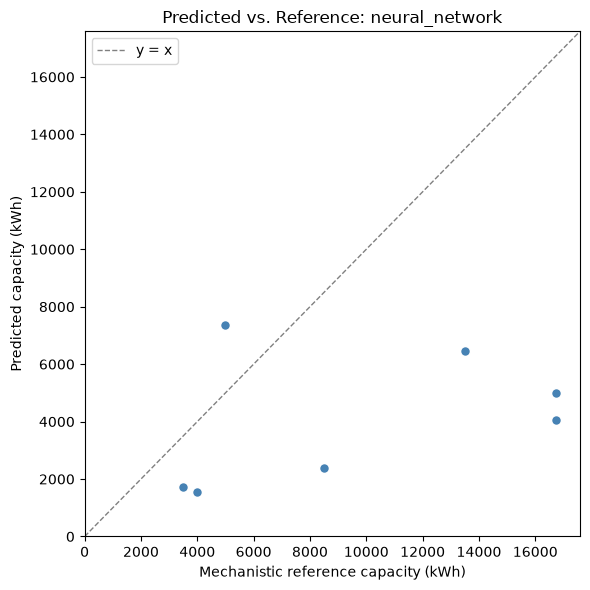

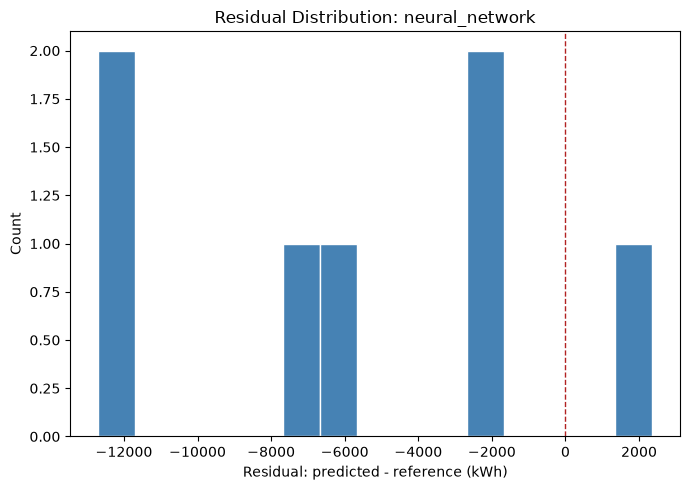

In [11]:
save_figure(plot_predicted_vs_reference(y_test, nn_pred, "neural_network"), FIGURES_DIR / "17_predicted_vs_reference_neural_network.png")
save_figure(plot_residual_distribution(y_test, nn_pred, "neural_network"), FIGURES_DIR / "18_residuals_neural_network.png")

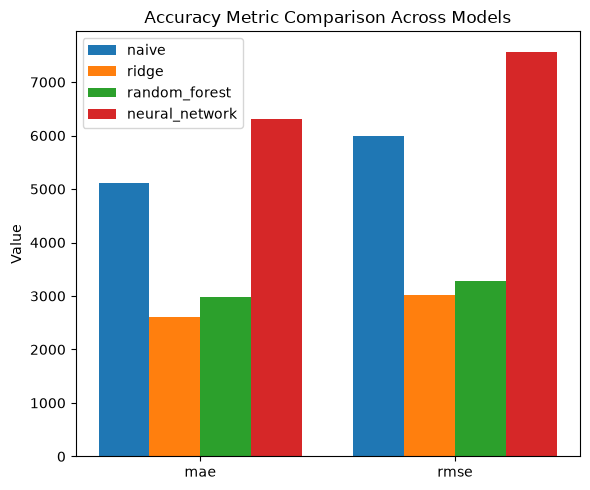

In [12]:
accuracy_dicts = {name: row.to_dict() for name, row in all_accuracy.iterrows()}
operational_dicts = {name: row.to_dict() for name, row in all_operational.iterrows()}

fig = plot_cross_model_metric_comparison(accuracy_dicts, ["mae", "rmse"])
save_figure(fig, FIGURES_DIR / "21_metric_comparison.png")

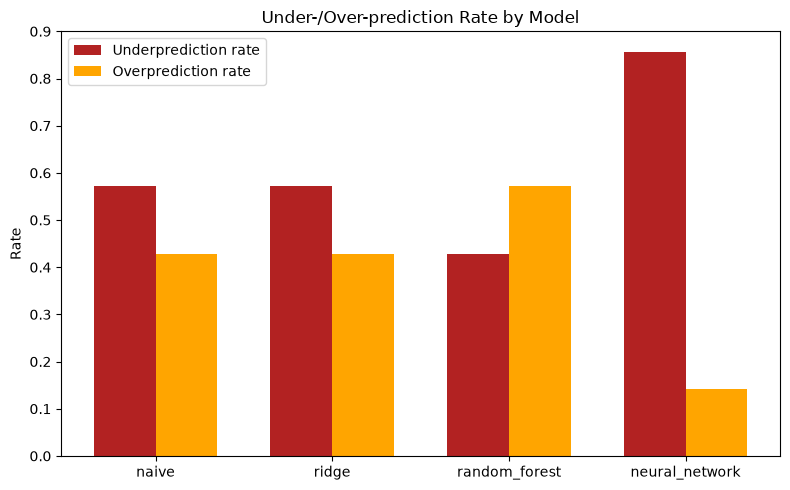

In [13]:
fig = plot_over_under_prediction_rates(operational_dicts)
save_figure(fig, FIGURES_DIR / "23_over_under_prediction.png")

## Stage 6 summary

- Built and trained the spec'd MLP (128-64-32, 10% dropout, ReLU output, Huber loss, Adam, early stopping + best-model checkpointing) via Keras/TensorFlow, exactly per `config/ml_training.yaml` and the refinement addendum's framework pin (§1.2) -- no architecture changes made to try to improve results.
- Trained on the identical 39/8/9 split and 37 features as the Stage 5 baselines, so the comparison is fair.
- Predictions are guaranteed non-negative (ReLU output activation + defensive `np.maximum(pred, 0)`).
- Result reported as observed, not adjusted: this run's numbers go into `outputs/tables/accuracy_metrics_by_model.csv` alongside the baselines for Stage 9's final comparison. Given the 9-sample test split, no single number here should be treated as a confident verdict on whether the neural network "wins" -- that is exactly why Stage 7's mandatory physical verification and Stage 9's full comparison (including the computational break-even analysis, §22) still need to happen before drawing conclusions about the research hypothesis (§2).

Saved: `models/neural_network/best_model.keras`, `models/preprocessing/scaler.pkl`, `models/preprocessing/feature_columns.pkl`.